# Import Required Libraries
Import libraries such as pandas, matplotlib, seaborn, and openpyxl for data manipulation and visualization.

In [12]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook

# Data Exploration and Column Analysis
This notebook explores the `output.xlsx` file and prints all column names for further analysis.

In [13]:
# Import Required Libraries
import pandas as pd
file_path = 'data/output.xlsx'

In [14]:
# Load the data
data = pd.read_excel(file_path)

In [15]:
# Print all column names
print('Columns in the dataset:', data.columns.tolist())

Columns in the dataset: ['Company name Latin alphabet', 'Quoted', 'Branch', 'Woco', 'NACE Rev. 2, core code (4 digits)', 'Consolidation code', 'Standardized country', 'Operating revenue (Turnover)\nEUR Last avail. yr', 'P/L before tax\nEUR Last avail. yr', 'P/L for period [=Net income]\nEUR Last avail. yr', 'Total assets\nEUR Last avail. yr', 'Shareholders funds\nEUR Last avail. yr', 'Current ratio\nLast avail. yr', 'Solvency ratio (Asset based)\nLast avail. yr', 'Number of employees\nLast avail. yr', 'Non-current assets\nEUR Last avail. yr', 'Intangible assets\nEUR Last avail. yr', 'Tangible fixed assets\nEUR Last avail. yr', 'Other non-current assets\nEUR Last avail. yr', 'Current assets\nEUR Last avail. yr', 'Stock\nEUR Last avail. yr', 'Debtors\nEUR Last avail. yr', 'Other current assets\nEUR Last avail. yr', 'Of which cash and cash equivalent\nEUR Last avail. yr', 'Capital\nEUR Last avail. yr', 'Other shareholders funds\nEUR Last avail. yr', 'Non-current liabilities\nEUR Last avai

C:\Users\Michael\AppData\Local\Temp\ipykernel_16780\2348472893.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\Michael\AppData\Local\Temp\ipykernel_16780\2348472893.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
C:\Users\Michael\AppData\Local\Temp\ipykernel_16780\2348472893.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
C:\Users\Michael\AppData\Local\Temp\ipykernel_16780\2348472893.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].

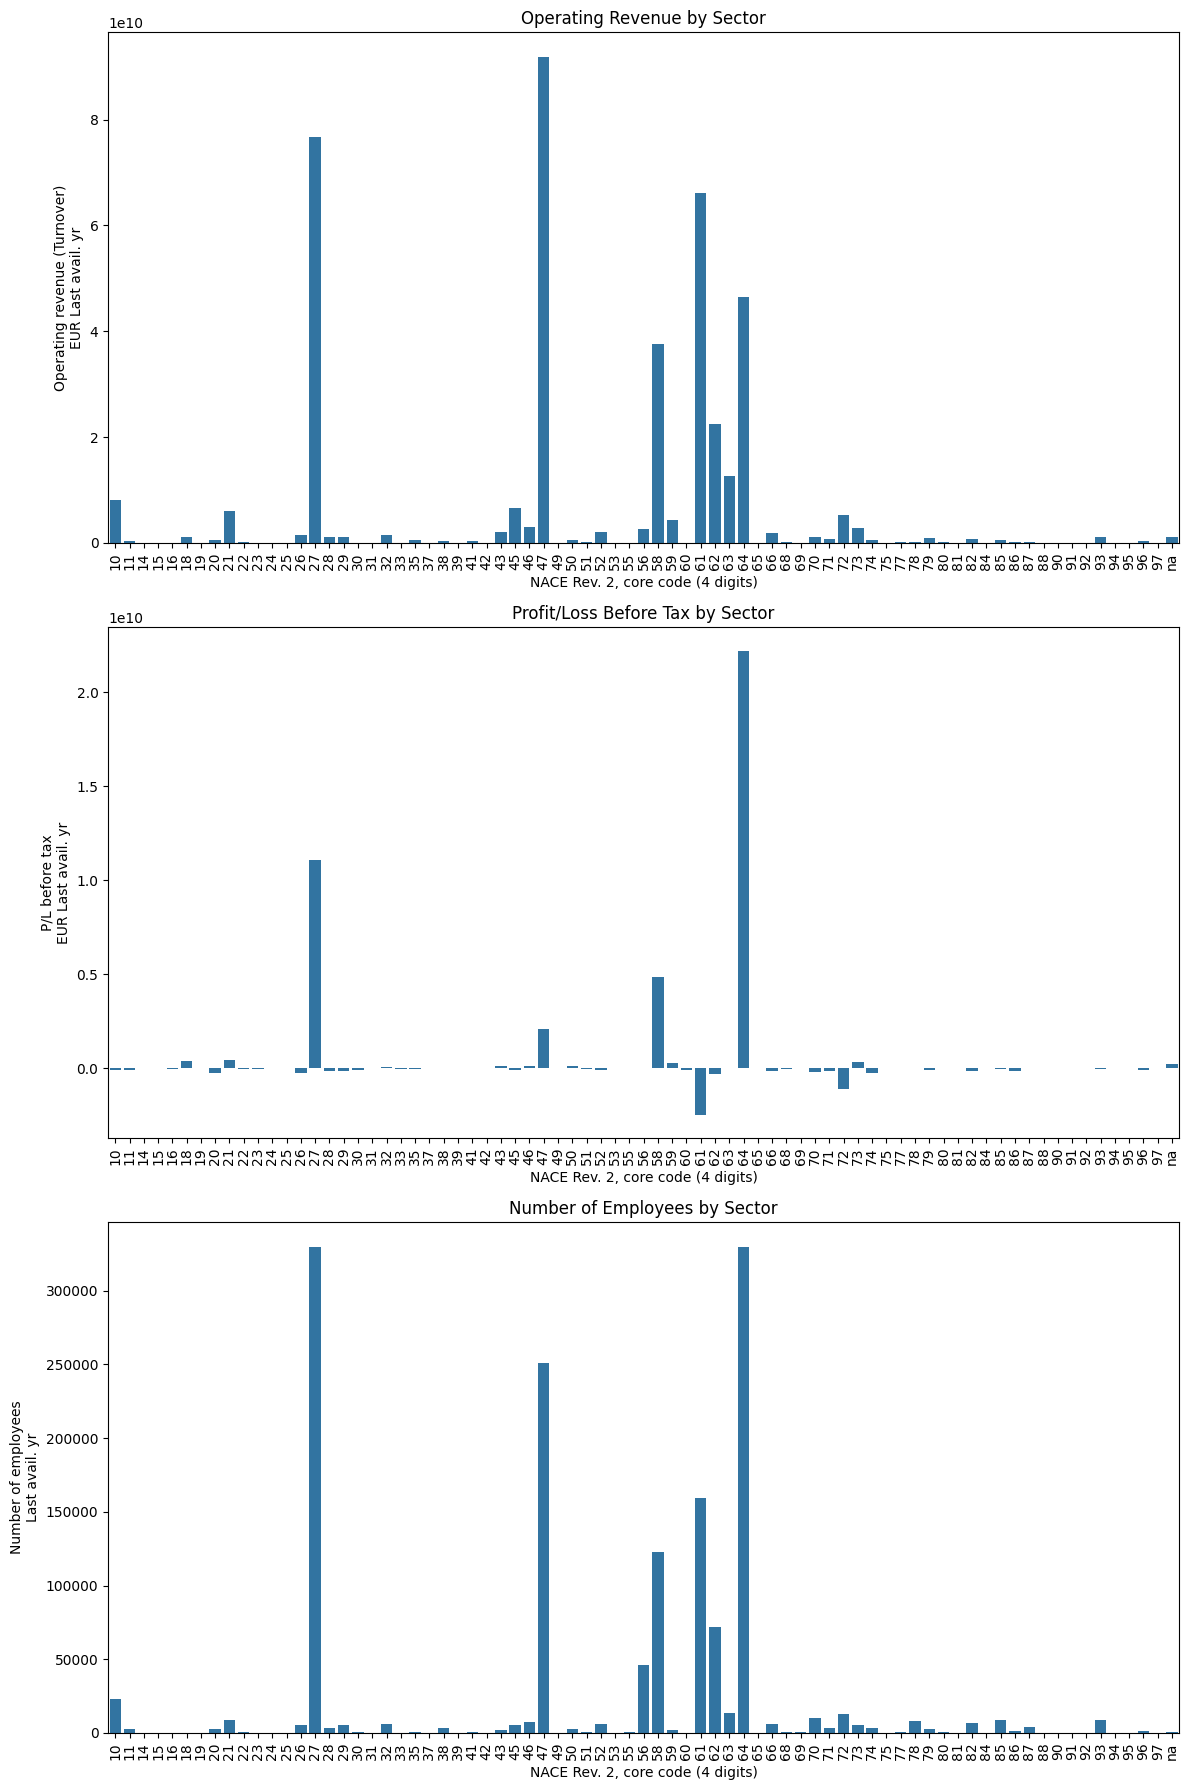

In [16]:
# Group data by sector (NACE Rev. 2, core code)
sector_data = data.groupby('NACE Rev. 2, core code (4 digits)').agg({
    'Operating revenue (Turnover)\nEUR Last avail. yr': 'sum',
    'P/L before tax\nEUR Last avail. yr': 'sum',
    'Number of employees\nLast avail. yr': 'sum'
}).reset_index()

# Plot sector-specific charts
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Operating revenue by sector
sns.barplot(data=sector_data, x='NACE Rev. 2, core code (4 digits)', 
            y='Operating revenue (Turnover)\nEUR Last avail. yr', ax=axes[0])
axes[0].set_title('Operating Revenue by Sector')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)

# Profit/Loss before tax by sector
sns.barplot(data=sector_data, x='NACE Rev. 2, core code (4 digits)', 
            y='P/L before tax\nEUR Last avail. yr', ax=axes[1])
axes[1].set_title('Profit/Loss Before Tax by Sector')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

# Number of employees by sector
sns.barplot(data=sector_data, x='NACE Rev. 2, core code (4 digits)', 
            y='Number of employees\nLast avail. yr', ax=axes[2])
axes[2].set_title('Number of Employees by Sector')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Analyze Active/Inactive Companies by NACE Code
This notebook explores the dataset to determine the number of active and inactive companies based on their NACE codes. The results are translated into meaningful insights.

In [17]:
# Import Required Libraries
import pandas as pd
file_path = 'data/output.xlsx'

In [18]:
# Load the data
data = pd.read_excel(file_path)

In [19]:
# Process the data
# Extract the first two characters of the NACE code for grouping
data['NACE Sector'] = data['NACE Rev. 2, core code (4 digits)'].astype(str).str[:2]

# Group by NACE Sector and Status
status_counts = data.groupby(['NACE Sector', 'Status Updated']).size().unstack(fill_value=0)

In [20]:
# Translate the results into meaningful insights
status_counts['Total'] = status_counts.sum(axis=1)
status_counts['Active Percentage'] = (status_counts['Active'] / status_counts['Total']) * 100
status_counts['Inactive Percentage'] = (status_counts['Inactive'] / status_counts['Total']) * 100

# Display the insights
print(status_counts)

Status Updated  Active  Inactive  Total  Active Percentage  \
NACE Sector                                                  
10                   7         6     13          53.846154   
11                   2         5      7          28.571429   
14                   2         2      4          50.000000   
15                   1         0      1         100.000000   
16                   4         5      9          44.444444   
...                ...       ...    ...                ...   
94                  11         3     14          78.571429   
95                   2         1      3          66.666667   
96                  28        30     58          48.275862   
97                   1         0      1         100.000000   
na                 280       158    438          63.926941   

Status Updated  Inactive Percentage  
NACE Sector                          
10                        46.153846  
11                        71.428571  
14                        50.000000  
15 

# Next Steps
Visualize the active/inactive percentages by NACE code to better understand the distribution.